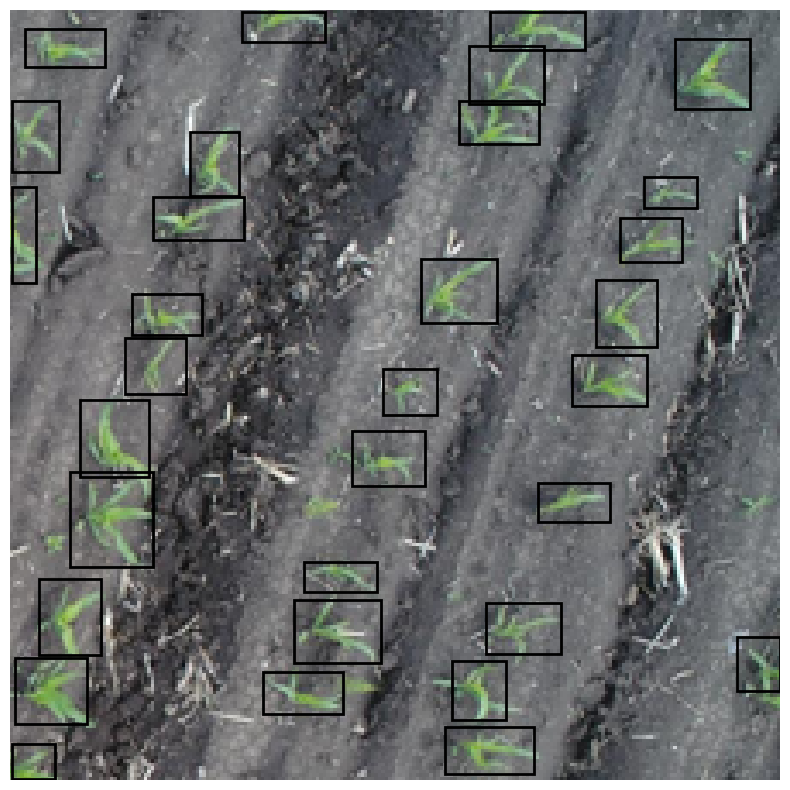

In [2]:
import os
import cv2
import matplotlib.pyplot as plt

# Function to plot image with bounding boxes
def plot_image_with_bboxes(image_path, label_path):
    # Read image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Read labels
    with open(label_path, 'r') as file:
        labels = file.readlines()
    
    # Plot image
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    
    # Plot bounding boxes
    for label in labels:
        label = label.strip().split()
        class_id, x_center, y_center, width, height = map(float, label)
        
        # Convert YOLO format to bounding box coordinates
        img_height, img_width, _ = image.shape
        x_center *= img_width
        y_center *= img_height
        width *= img_width
        height *= img_height
        
        x_min = int(x_center - width / 2)
        y_min = int(y_center - height / 2)
        x_max = int(x_center + width / 2)
        y_max = int(y_center + height / 2)
        
        # Draw bounding box
        plt.gca().add_patch(plt.Rectangle((x_min, y_min), width, height, edgecolor='black', facecolor='none', linewidth=2))
    
    plt.axis('off')
    plt.show()

# Example usage
image_path = 'dataset/out_domain/maize_seedling_detection/yolo_dataset/e480cd0-2_jpg.rf.f28934b568bb7776f238cc62b72da23a.tif'
label_path = 'dataset/out_domain/maize_seedling_detection/yolo_dataset/e480cd0-2_jpg.rf.f28934b568bb7776f238cc62b72da23a.txt'
plot_image_with_bboxes(image_path, label_path)